## Generate Playlists

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from scipy.spatial.distance import cdist

### Load the previously trained model

In [2]:
model = load_model(
    "../models/lstm_next_track.keras"
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 7, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,849 (362.70 KB)

 Trainable params: 30,949 (120.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,900 (241.80 KB)

### Load Dataset

In [3]:
df = pd.read_csv(
    "../data/spotify_tracks.csv"
)

In [4]:
mood_features = [
    "energy",
    "valence",
    "danceability",
    "acousticness",
    "tempo"
]

### Load Sequences

In [5]:
import json

with open(
    "../data/sequences.json",
    "r"
) as f:
    all_sequences = json.load(f)

In [6]:
candidate_pool = df.sample(
    300,
    random_state=42
).copy()

In [33]:
seed_sequence = all_sequences[0]
input_track_ids = seed_sequence[:5]

current_window = (
    df.loc[
        input_track_ids,
        mood_features
    ]
    .astype(float)
    .values
)

### Initialize Playlist

In [34]:
playlist_track_ids = input_track_ids.copy()
playlist_track_ids

[168, 835, 959, 500, 1]

### Predictor Function

In [25]:
def predict_next_features(
    model,
    sequence_window
):

    X = np.array(
        sequence_window,
        dtype=np.float32
    )

    X = np.expand_dims(
        X,
        axis=0
    )

    prediction = model.predict(
        X,
        verbose=0
    )

    return prediction[0]

In [20]:
def find_closest_track(
    predicted_vector,
    candidate_pool,
    mood_features
):

    candidate_vectors = (
        candidate_pool[mood_features]
        .values
    )

    distances = cdist(
        [predicted_vector],
        candidate_vectors,
        metric="euclidean"
    )[0]

    best_idx = np.argmin(
        distances
    )

    return (
        candidate_pool.iloc[best_idx],
        distances[best_idx]
    )

In [21]:
df[mood_features].dtypes

energy          float64
valence         float64
danceability    float64
acousticness    float64
tempo           float64
dtype: object

In [22]:
print(current_window.shape)
print(current_window.dtype)

print(current_window)

(5, 5)
float64
[[1.2600e-01 2.7900e-01 4.7900e-01 9.6600e-01 9.6327e+01]
 [1.2400e-01 2.5700e-01 4.8900e-01 9.5200e-01 9.1386e+01]
 [8.1200e-02 2.4300e-01 4.2600e-01 9.4800e-01 8.5204e+01]
 [1.1400e-01 2.6900e-01 3.8500e-01 9.1700e-01 9.3314e+01]
 [1.6600e-01 2.6700e-01 4.2000e-01 9.2400e-01 7.7489e+01]]


### Generate remaining playtlist

In [26]:
PLAYLIST_LENGTH = 8

while len(playlist_track_ids) < PLAYLIST_LENGTH:

    predicted_vector = predict_next_features(
        model,
        current_window
    )

    next_track, distance = (
        find_closest_track(
            predicted_vector,
            candidate_pool,
            mood_features
        )
    )

    next_track_id = next_track.name

    playlist_track_ids.append(
        next_track_id
    )

    candidate_pool = (
        candidate_pool.drop(
            next_track_id
        )
    )

    next_features = (
        next_track[mood_features]
        .astype(float)
        .values
    )

    current_window = np.vstack([
        current_window[1:],
        next_features
    ])

In [27]:
playlist_df = df.loc[
    playlist_track_ids
]

In [28]:
playlist_df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
168,168,3tob5ofeuvFKKSbOTldenC,The Mayries,Overpass Graffiti,Overpass Graffiti,54,226603,False,0.479,0.1260,...,-13.974,1,0.0303,0.9660,0.000000,0.113,0.279,96.327,4,acoustic
835,835,1SPZoobx8PZYoZP9xBXl6P,Jay Filson,"Don't Think Twice, It's All Right (Acoustic)","Don't Think Twice, It's All Right - Acoustic",26,210901,False,0.489,0.1240,...,-10.145,1,0.0436,0.9520,0.000000,0.243,0.257,91.386,4,acoustic
959,959,6VJcMjtcbFGAwZxqW28C8Q,Roberto Diana;Muniesa,Muniesa,Cortes de Aragón,47,72167,False,0.426,0.0812,...,-21.651,0,0.0843,0.9480,0.889000,0.107,0.243,85.204,5,acoustic
500,500,4dzurJ1Q1LIr8X7doV3yT0,Jonah Baker,A Thousand Years (Acoustic),A Thousand Years - Acoustic,44,249728,False,0.385,0.1140,...,-13.005,1,0.0314,0.9170,0.000000,0.128,0.269,93.314,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
34641,34641,5FcQcDHuwpzP70vhlCqVi2,Steppenwolf,Fiesta temática 60s,The Pusher,0,349826,False,0.508,0.4700,...,-9.339,1,0.0262,0.2010,0.055300,0.140,0.690,81.016,4,folk
34192,34192,34a89MbC7QXsUsLkljLgXX,Tom Petty,80s Bangers Vol. 1,Free Fallin',1,255680,False,0.619,0.5040,...,-11.562,1,0.0250,0.0614,0.000000,0.060,0.568,84.335,4,folk
84138,84138,5Yi7LVz0rVo2aYN34Hyv1U,Cream,(60's) Sixties Collected Volume 2,I Feel Free - Remastered,0,172760,False,0.371,0.6010,...,-8.431,1,0.0277,0.1370,0.000055,0.150,0.596,87.975,4,psych-rock


### Plot Mood Journey

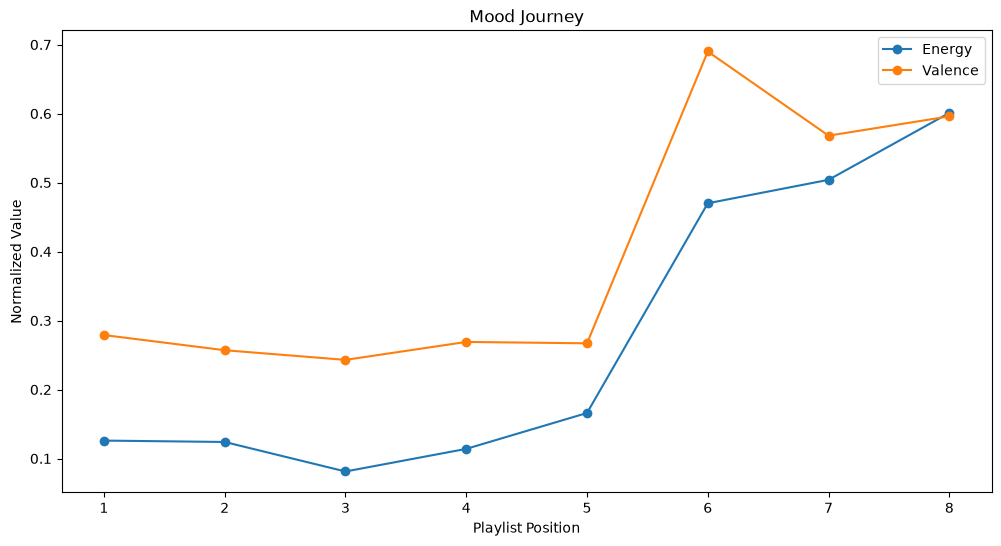

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    playlist_df["energy"].values,
    marker="o",
    label="Energy"
)

plt.plot(
    playlist_df["valence"].values,
    marker="o",
    label="Valence"
)

plt.xticks(
    range(len(playlist_df)),
    range(1, len(playlist_df)+1)
)

plt.xlabel(
    "Playlist Position"
)

plt.ylabel(
    "Normalized Value"
)

plt.title(
    "Mood Journey"
)

plt.legend()

plt.show()

### Computer Smoothness Score

In [30]:
def smoothness_score(
    feature_matrix
):

    distances = []

    for i in range(
        len(feature_matrix)-1
    ):

        d = np.linalg.norm(
            feature_matrix[i+1]
            -
            feature_matrix[i]
        )

        distances.append(d)

    return np.mean(
        distances
    )

In [31]:
playlist_features = (
    playlist_df[mood_features]
    .values
)

generated_score = (
    smoothness_score(
        playlist_features
    )
)

print(
    "Generated Playlist:",
    generated_score
)

Generated Playlist: 6.52495351749817


### Generate Random Playlist Baseline

In [32]:
random_playlist = df.sample(
    len(playlist_df),
    random_state=123
)

random_score = (
    smoothness_score(
        random_playlist[
            mood_features
        ].values
    )
)

print(
    "Random Playlist:",
    random_score
)

Random Playlist: 24.325505921226817
